<a href="https://colab.research.google.com/github/muratal49/CodingProblems/blob/main/Iris_Clustering_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MURAT AL
## Extra Credit: Clustering Algoirthms on Iris Dataset

We will compare different clustering algorithms based on their homogenity scores on splitting Iris Dataset to k=3 clusters.

The algorithms to be tested for (k=3) are:

1- K-means

2- Mini Batch K-means


3- Agglomerative Clustering  

4- Spectral Clustering



In [1]:
#importing libraries and the data set:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
iris = datasets.load_iris()

#Clustering Algos
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import homogeneity_score

In [4]:
#Checking the data set:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

As seen aboce there are 3 types in the target column: 'setosa', 'versicolor', 'virginica'. We will apply an Unsupervised approach here to cluster.


In [53]:
#Defining the predictors as df and trying to see how well we can split them into 3 wihouts knowing their categories:

df=pd.DataFrame(iris.data)


In [6]:
#initialize algo objects:
kmeans=KMeans(n_clusters=3)
mbkmeans=MiniBatchKMeans(n_clusters=3)
aggclust=AgglomerativeClustering(n_clusters=3)
specclust=SpectralClustering(n_clusters=3)

#put them in a list so we can iterate:
clusterings=[kmeans,mbkmeans,aggclust,specclust]


In [50]:
#iterate over 4 clustering methods in the list and compare their homegenity scores:

df_homegenity=pd.DataFrame()
for cluster in clusterings:
  cluster.fit(df)
  homogenity=homogeneity_score(iris.target,cluster.labels_)
  df1 = pd.DataFrame({'Homogeneity': [round(homogenity, 3)]}, index=[str(cluster)])
  df_homegenity = pd.concat([df_homegenity, df1])

df_homegenity.columns=['Homogenity Score']
df_homegenity.sort_values(by='Homogenity Score',ascending=False)


,Homogenity Score
SpectralClustering(n_clusters=3),0.787
AgglomerativeClustering(n_clusters=3),0.761
MiniBatchKMeans(n_clusters=3),0.743
KMeans(n_clusters=3),0.736


In [12]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [13]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

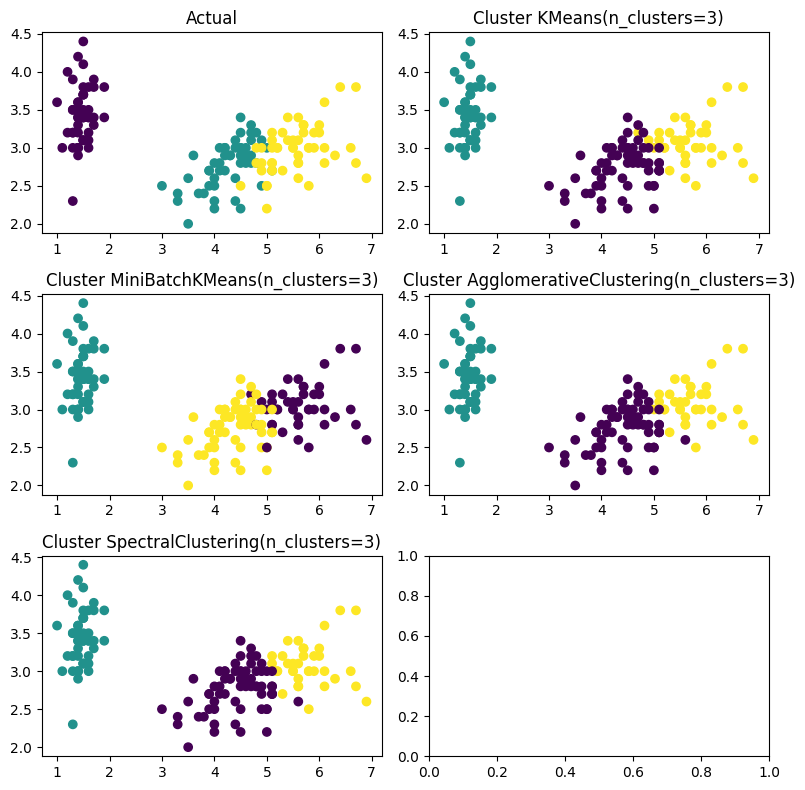

In [52]:
#comparing the actual target and clustering resulrs in color plots:

fig, ax = plt.subplots(3, 2, figsize=(8, 8))  # 3x2 grid

ax[0, 0].scatter(df[2], df[1], c=iris.target)  # First plot (Actual Data)
ax[0, 0].set_title('Actual')

for i, cluster in enumerate(clusterings):
    cluster.fit(df)  # Fit the clustering model

    row, col = divmod(i + 1, 2)  # Convert index to (row, col) position
    ax[row, col].scatter(df[2], df[1], c=cluster.labels_)
    ax[row, col].set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()
#